In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold,cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.model_selection import RandomizedSearchCV
from matplotlib import pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

In [3]:
df = pd.read_csv("Customer_Churn_Data_V3.csv")

In [4]:
features = df.drop(columns = ['Churn'])

In [5]:
target = df['Churn']

In [6]:
features

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,InternetService_DSL,...,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Contract_Month-to-month,Contract_One year,Contract_Two year,MultipleLines_No,MultipleLines_No phone service,MultipleLines_Yes
0,0,0,1,0,1,0,1,29.85,29.85,1.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,1,0,0,0,34,1,0,56.95,1889.50,1.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0
2,1,0,0,0,2,1,1,53.85,108.15,1.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0
3,1,0,0,0,45,0,0,42.30,1840.75,1.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
4,0,0,0,0,2,1,1,70.70,151.65,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,1,0,1,1,24,1,1,84.80,1990.50,1.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
7028,0,0,1,1,72,1,1,103.20,7362.90,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
7029,0,0,1,1,11,0,1,29.60,346.45,1.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
7030,1,1,1,0,4,1,1,74.40,306.60,0.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0


In [7]:
target

0       0
1       0
2       1
3       0
4       1
       ..
7027    0
7028    0
7029    0
7030    1
7031    0
Name: Churn, Length: 7032, dtype: int64

In [8]:
features_train,features_test,target_train,target_test = train_test_split(features,target,test_size=0.2,random_state=42)

In [9]:
scaler = StandardScaler()
features_train = scaler.fit_transform(features_train)  # fit+transform on train
features_test = scaler.transform(features_test)         # only transform on test

In [10]:
smote = SMOTE(random_state=42)

# Apply SMOTE only on training data
features_train_resampled, target_train_resampled = smote.fit_resample(features_train, target_train)

print("Before SMOTE:", target.value_counts())
print("After SMOTE:", target_train_resampled.value_counts())

Before SMOTE: Churn
0    5163
1    1869
Name: count, dtype: int64
After SMOTE: Churn
1    4130
0    4130
Name: count, dtype: int64


In [11]:
lr = LogisticRegression(max_iter=1000,random_state=42)
lr.fit(features_train_resampled,target_train_resampled)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [12]:
target_pred = lr.predict(features_test)

In [13]:
models = {
    'Logistic Regression':LogisticRegression(max_iter=1000,random_state=42),
    'Random Forest':RandomForestClassifier(n_estimators=1000,random_state=42),
    'XGBoost':XGBClassifier(n_estimators=100,random_state=42)
}

for name, model in models.items():
    model.fit(features_train_resampled, target_train_resampled)
    preds = model.predict(features_test)

    print(f"{name}")
    print(f"  Accuracy  : {accuracy_score(target_test, preds):.4f}")
    print(f"  Precision : {precision_score(target_test, preds):.4f}")
    print(f"  Recall    : {recall_score(target_test, preds):.4f}")
    print(f"  F1 Score  : {f1_score(target_test, preds):.4f}")
    print(classification_report(target_test, preds))
    print("------------------------------------")

Logistic Regression
  Accuracy  : 0.7370
  Precision : 0.5034
  Recall    : 0.7941
  F1 Score  : 0.6162
              precision    recall  f1-score   support

           0       0.91      0.72      0.80      1033
           1       0.50      0.79      0.62       374

    accuracy                           0.74      1407
   macro avg       0.70      0.76      0.71      1407
weighted avg       0.80      0.74      0.75      1407

------------------------------------
Random Forest
  Accuracy  : 0.7832
  Precision : 0.5930
  Recall    : 0.5882
  F1 Score  : 0.5906
              precision    recall  f1-score   support

           0       0.85      0.85      0.85      1033
           1       0.59      0.59      0.59       374

    accuracy                           0.78      1407
   macro avg       0.72      0.72      0.72      1407
weighted avg       0.78      0.78      0.78      1407

------------------------------------
XGBoost
  Accuracy  : 0.7669
  Precision : 0.5593
  Recall    : 0.5802

In [14]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': ['balanced', None]
}

rf = RandomForestClassifier(random_state=42)

rf_search = RandomizedSearchCV(
    rf,
    param_distributions=param_grid,
    n_iter=20,
    scoring='recall',
    cv=5,
    random_state=42,
    n_jobs=-1
)

rf_search.fit(features_train_resampled, target_train_resampled)

print("Best Params:", rf_search.best_params_)
print("Best Recall:", rf_search.best_score_)

Best Params: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 10, 'class_weight': None}
Best Recall: 0.8709443099273608


In [15]:
best_rf = rf_search.best_estimator_

preds = best_rf.predict(features_test)

print(f"Accuracy  : {accuracy_score(target_test, preds):.4f}")
print(f"Precision : {precision_score(target_test, preds):.4f}")
print(f"Recall    : {recall_score(target_test, preds):.4f}")
print(f"F1 Score  : {f1_score(target_test, preds):.4f}")
print(classification_report(target_test, preds))

Accuracy  : 0.7598
Precision : 0.5373
Recall    : 0.6925
F1 Score  : 0.6051
              precision    recall  f1-score   support

           0       0.88      0.78      0.83      1033
           1       0.54      0.69      0.61       374

    accuracy                           0.76      1407
   macro avg       0.71      0.74      0.72      1407
weighted avg       0.79      0.76      0.77      1407



In [16]:
xgb_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0],
    'scale_pos_weight': [1, 2, 3]
}

xgb = XGBClassifier(random_state=42)
xgb_search = RandomizedSearchCV(
    xgb,
    param_distributions=xgb_param_grid,
    n_iter=20,
    scoring='recall',
    cv=5,
    random_state=42,
    n_jobs=-1
)

xgb_search.fit(features_train_resampled, target_train_resampled)

print("Best Params:", xgb_search.best_params_)
print("Best Recall:", xgb_search.best_score_)

Best Params: {'subsample': 0.7, 'scale_pos_weight': 3, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.01}
Best Recall: 0.9740316040309729


In [17]:
best_xgb = xgb_search.best_estimator_

preds_xgb = best_xgb.predict(features_test)

print(f"Accuracy  : {accuracy_score(target_test, preds_xgb):.4f}")
print(f"Precision : {precision_score(target_test, preds_xgb):.4f}")
print(f"Recall    : {recall_score(target_test, preds_xgb):.4f}")
print(f"F1 Score  : {f1_score(target_test, preds_xgb):.4f}")
print(classification_report(target_test, preds_xgb))

Accuracy  : 0.5615
Precision : 0.3733
Recall    : 0.9572
F1 Score  : 0.5371
              precision    recall  f1-score   support

           0       0.96      0.42      0.58      1033
           1       0.37      0.96      0.54       374

    accuracy                           0.56      1407
   macro avg       0.67      0.69      0.56      1407
weighted avg       0.81      0.56      0.57      1407



In [18]:
xgb_search2 = RandomizedSearchCV(
    XGBClassifier(random_state=42),
    param_distributions=xgb_param_grid,
    n_iter=20,
    scoring='f1',  # changed from recall to f1
    cv=5,
    random_state=42,
    n_jobs=-1
)

xgb_search2.fit(features_train_resampled, target_train_resampled)
print("Best Params:", xgb_search2.best_params_)
print("Best F1:", xgb_search2.best_score_)

Best Params: {'subsample': 1.0, 'scale_pos_weight': 3, 'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.05}
Best F1: 0.7708631097961176


In [19]:
best_xgb2 = xgb_search2.best_estimator_

preds_xgb2 = best_xgb2.predict(features_test)

print(f"Accuracy  : {accuracy_score(target_test, preds_xgb2):.4f}")
print(f"Precision : {precision_score(target_test, preds_xgb2):.4f}")
print(f"Recall    : {recall_score(target_test, preds_xgb2):.4f}")
print(f"F1 Score  : {f1_score(target_test, preds_xgb2):.4f}")
print(classification_report(target_test, preds_xgb2))

Accuracy  : 0.7207
Precision : 0.4829
Recall    : 0.7166
F1 Score  : 0.5770
              precision    recall  f1-score   support

           0       0.88      0.72      0.79      1033
           1       0.48      0.72      0.58       374

    accuracy                           0.72      1407
   macro avg       0.68      0.72      0.68      1407
weighted avg       0.77      0.72      0.73      1407



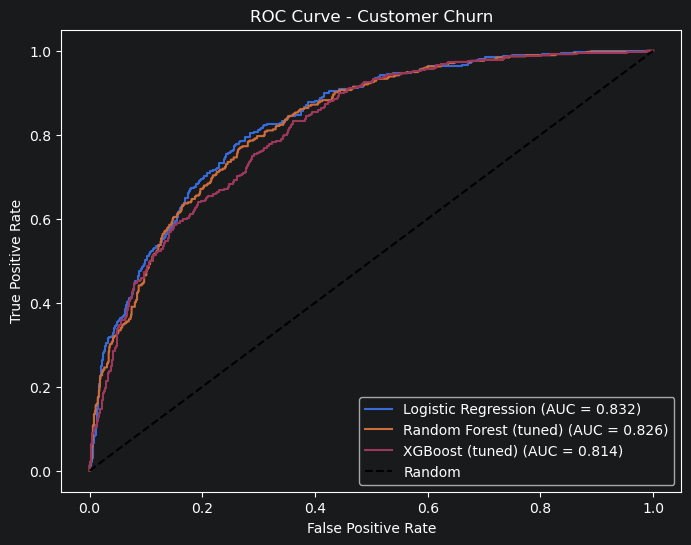

In [20]:
models_final = {
    'Logistic Regression': lr,
    'Random Forest (tuned)': best_rf,
    'XGBoost (tuned)': best_xgb2
}

plt.figure(figsize=(8, 6))

for name, model in models_final.items():
    probs = model.predict_proba(features_test)[:, 1]
    fpr, tpr, _ = roc_curve(target_test, probs)
    auc = roc_auc_score(target_test, probs)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

plt.plot([0,1], [0,1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Customer Churn')
plt.legend()
plt.show()

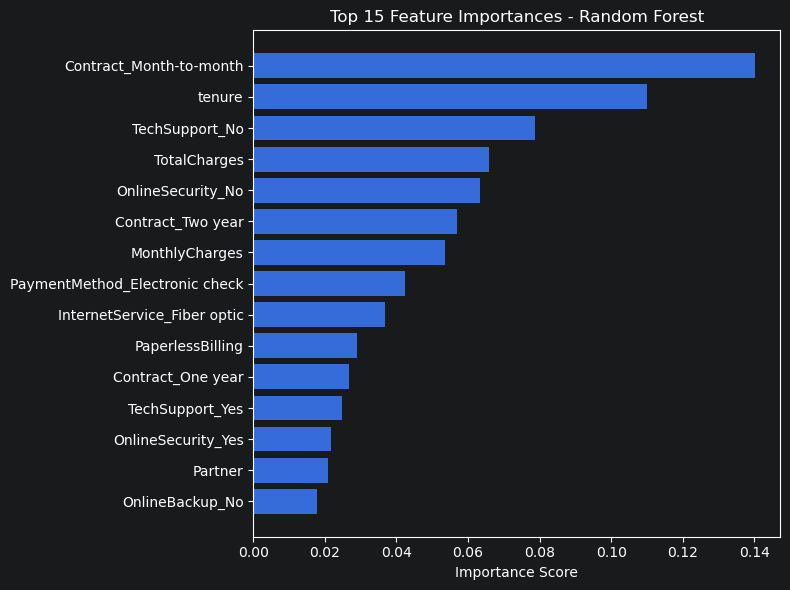

In [21]:
importance = pd.Series(
    best_rf.feature_importances_,
    index=features.columns
).sort_values(ascending=False)[:15]

plt.figure(figsize=(8, 6))
plt.barh(importance.index[::-1], importance.values[::-1])
plt.xlabel('Importance Score')
plt.title('Top 15 Feature Importances - Random Forest')
plt.tight_layout()
plt.show()

In [22]:
import joblib
joblib.dump(lr, 'Logistic_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

In [23]:
features.shape

(7032, 40)